[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T03_F_narrative_llm_central_banks_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Tema 3 — Comunicación de Bancos Centrales, Orientación Futura y Tono de Política Monetaria

**Macroeconomía Avanzada · Máster en Análisis Económico Aplicado (MAV)**

En la macroeconomía monetaria moderna, la comunicación de la banca central no es retórica superflua ni comentario pasivo: constituye un instrumento activo de política económica. Como demostró Michael Woodford (2005) en *"Central Bank Communication and Policy Effectiveness"*, la política monetaria ejerce su influencia macroeconómica primordial no a través de la tasa de fondeo a un día fijada hoy, sino mediante el anclaje y gestión de las expectativas del sector privado sobre la trayectoria futura esperada de las tasas de interés, la inflación y la holgura económica.

Cuando un banco central publica un comunicado de política monetaria o las minutas de su reunión de gobierno, los mercados financieros y los agentes fijadores de precios absorben dos componentes diferenciados de información (Gürkaynak, Sack y Swanson, 2005; Campbell et al., 2012):
1. **Factor Objetivo (Sorpresa de Acción)**: El movimiento imprevisto en la tasa de interés de referencia fijada en la reunión corriente:
   $$\text{Sorpresa}_t^{\text{objetivo}} = i_t - \mathbb{E}_{t^-}[i_t]$$
2. **Factor Trayectoria (Sorpresa de Orientación Futura / Forward Guidance)**: La revisión en las expectativas de mercado sobre la senda futura de la política monetaria a lo largo de los trimestres venideros, transmitida mediante el tono cualitativo, el balance de riesgos y el diagnóstico macroeconómico:
   $$\text{Sorpresa}_t^{\text{trayectoria}} = \mathbb{E}_t\left[\sum_{s=1}^H i_{t+s}\right] - \mathbb{E}_{t^-}\left[\sum_{s=1}^H i_{t+s}\right]$$

En este módulo, abandonamos cualquier aproximación sintética e implementamos medición textual empírica genuina sobre la comunicación de la banca central. Utilizando registros empíricos auténticos de postura de política monetaria de Banco de México (Banxico) y de la Reserva Federal (Fed):
- Cuantificamos el tono narrativo del banco central empleando diccionarios macroeconómicos especializados (`puremacro.narrative`).
- Construimos métricas continuas de postura monetaria mediante geometría en espacios vectoriales TF-IDF y similitud coseno frente a prototipos de política (Restrictiva / *Hawkish* vs. Acomodaticia / *Dovish*).
- Estimamos regresiones econométricas predictivas con errores estándar robustos HAC (Newey-West) para contrastar si la orientación narrativa anticipa sistemáticamente las decisiones de tasa en la siguiente reunión.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from puremacro.regress import ols, add_constant

import _nbstyle
from _datos import DATOS
from puremacro.narrative import (
    score_spanish_macro_sentiment,
    SPANISH_MACRO_LEXICON,
    TfidfVectorizer,
)

_nbstyle.apply_style()
print("Módulos cargados y estilo de publicación inicializado.")

Módulos cargados y estilo de publicación inicializado.


## 1. Registros Empíricos de Banca Central: Banxico y la Reserva Federal

Para llevar a cabo un análisis empírico riguroso, importamos dos series temporales históricas de `data_curso/`:
1. **`banxico_stance_monthly.csv`**: Registro mensual que abarca de 2000 a 2026 para Banco de México. Contiene:
   - `banxico_direction`: La decisión discreta de tasa de interés en cada reunión ($+1$ para alza, $0$ para pausa/mantenimiento, $-1$ para recorte).
   - `banxico_stance_signed`: El índice acumulado de postura monetaria con signo, reflejando el régimen de política imperante.
   - `tight_stance_narr`: Un indicador binario derivado de la narrativa textual de los comunicados y minutas oficiales de Banxico, identificando periodos donde la autoridad comunicó explícitamente una postura restrictiva.
2. **`FEDFUNDS.csv`**: Tasa efectiva de fondos federales mensual de la Reserva Federal (FRED), desde 1954 hasta 2026.

En economías abiertas y pequeñas como México, la política monetaria responde tanto a la dinámica inflacionaria doméstica como a las condiciones financieras internacionales—particularmente a las decisiones de la Reserva Federal (Clarida, Galí y Gertler, 2002; Rey, 2015). Alineamos ambas series en un panel macroeconómico mensual unificado.

In [3]:
# Cargar datos mensuales de postura de Banxico y tasa de Fondos Federales
df_banxico = pd.read_csv(DATOS / "banxico_stance_monthly.csv", parse_dates=["date"]).set_index("date")
df_fed = pd.read_csv(DATOS / "FEDFUNDS.csv", parse_dates=["observation_date"]).rename(
    columns={"observation_date": "date"}
).set_index("date")

# Unificar panel macroeconómico mensual
df_macro = df_banxico.join(df_fed, how="inner").sort_index()

# Construir dirección de política adelantada (t+1) e innovación de tasa Fed (Delta Fed_t)
df_macro["next_direction"] = df_macro["banxico_direction"].shift(-1)
df_macro["d_fed"] = df_macro["FEDFUNDS"].diff()

print(f"Periodo muestral: {df_macro.index.min().strftime('%Y-%m')} a {df_macro.index.max().strftime('%Y-%m')}")
print(f"Total de observaciones mensuales alineadas: {len(df_macro)}")
print("\nDistribución de decisiones de tasa de Banxico:")
print(df_macro["banxico_direction"].value_counts().rename({1.0: "Alzas (+1)", 0.0: "Pausas (0)", -1.0: "Recortes (-1)"}))

Periodo muestral: 2000-01 a 2026-04
Total de observaciones mensuales alineadas: 316

Distribución de decisiones de tasa de Banxico:
banxico_direction
Pausas (0)       208
Alzas (+1)        60
Recortes (-1)     48
Name: count, dtype: int64


## 2. Puntuación de Postura Textual mediante Diccionarios Macroeconómicos Especializados

Los diccionarios genéricos de análisis de sentimiento (como VADER o LIWC) fracasan al aplicarse a la prosa económica (Loughran y McDonald, 2011). En la comunicación de la banca central, términos como *"restrictivo"*, *"apretamiento"* o *"enfriamiento"* no expresan pesimismo emocional, sino una postura deliberada de contracción monetaria dirigida a anclar las expectativas de inflación.

Para cuantificar la postura monetaria, `puremacro.narrative` provee diccionarios especializados (`SPANISH_MACRO_LEXICON`) estructurados en cuatro dimensiones analíticas:
1. **Términos Restrictivos / Hawkish** ($N_{\text{hawk}}$): Expresiones de alzas de tasa, endurecimiento monetario, presiones sobre inflación subyacente y riesgo de desanclaje (*"postura restrictiva"*, *"alza de tasas"*, *"presiones inflacionarias"*, *"anclar las expectativas"*).
2. **Términos Acomodaticios / Dovish** ($N_{\text{dove}}$): Expresiones de recortes de tasa, relajamiento, holgura económica y debilidad de la demanda (*"postura acomodaticia"*, *"recorte de tasas"*, *"holgura económica"*, *"desaceleración"*).
3. **Incertidumbre Inflacionaria** ($N_{\text{unc}}$): Traspaso cambiario, depreciación de la divisa y choques de oferta (*"traspaso cambiario"*, *"incertidumbre sobre precios"*).
4. **Estrés Financiero** ($N_{\text{str}}$): Riesgo de crédito, volatilidad de mercados y tensión de liquidez (*"estrés financiero"*, *"aversión al riesgo"*).

El índice de **Postura Neta** (*Net Stance*) se formaliza como:
$$\text{Postura Neta} = \frac{N_{\text{hawk}} - N_{\text{dove}}}{N_{\text{hawk}} + N_{\text{dove}} + \varepsilon} \in [-1.0, +1.0]$$
donde $+1.0$ representa restricción pura y $-1.0$ denota relajamiento puro.

In [4]:
# Diccionario de dominio para la comunicación de banca central en español
# (es el mismo SPANISH_MACRO_LEXICON de puremacro, escrito aquí para poder editarlo)
MACRO_LEXICON = {
    "hawkish": [
        "postura restrictiva", "postura contractiva", "alza de tasas",
        "aumento de tasas", "incremento en la tasa", "presiones inflacionarias",
        "presiones de costos", "balance de riesgos sesgado al alza", "sobrecalentamiento",
        "anclar las expectativas", "desanclaje de expectativas", "endurecimiento monetario",
        "restringir la liquidez", "contener la inflacion", "contener la inflación",
        "riesgos inflacionarios", "inflacion subyacente elevada", "inflación subyacente elevada",
        "choque inflacionario", "segundo orden", "efectos de segundo orden",
        "resistencia a la baja", "rigidez de precios", "demanda agregada sobrecalentada",
        "apretamiento cuantitativo", "mantener la cautela",
    ],
    "dovish": [
        "postura acomodaticia", "recorte de tasas", "disminución de tasas", "reducción de tasas",
        "baja en la tasa", "holgura económica", "brecha del producto negativa",
        "balance de riesgos sesgado a la baja", "desaceleración económica", "debilitamiento de la demanda",
        "estímulo monetario", "relajamiento monetario", "flexibilización monetaria",
        "convergencia de la inflación", "trayectoria descendente", "alivio en costos",
        "menores presiones", "atenuación de presiones", "enfriamiento del mercado laboral",
        "espacio para recortar", "ciclo de recortes", "facilitar el crédito",
    ],
    "inflation_uncertainty": [
        "incertidumbre sobre precios", "volatilidad cambiaria", "depreciación del peso",
        "traspaso cambiario", "pass-through", "choque de oferta",
        "disrupciones en cadenas", "precios de energéticos", "precios agropecuarios",
        "persistencia inflacionaria", "anomalías en precios", "volatilidad en materias primas",
    ],
    "financial_stress": [
        "estrés financiero", "volatilidad en mercados", "aversión al riesgo", "salida de capitales",
        "riesgo soberano", "ampliación de diferenciales", "riesgo crediticio",
        "morosidad", "vulnerabilidad bancaria", "tensión de liquidez",
    ],
}

# Declaraciones representativas de política monetaria en tres regímenes macroeconómicos
statements = [
    (
        "Ciclo Restrictivo (2022)",
        "La Junta de Gobierno decidió incrementar el objetivo para la Tasa de Interés Interbancaria a un día en 50 puntos base. "
        "Las persistentes presiones inflacionarias globales y el balance de riesgos sesgado al alza exigen mantener una postura restrictiva "
        "para anclar las expectativas de inflación en el horizonte de pronóstico."
    ),
    (
        "Ciclo Acomodaticio (2020)",
        "La Junta de Gobierno redujo la tasa de referencia para proveer estímulo monetario ante la severa desaceleración económica, "
        "la ampliación de la brecha del producto negativa y el enfriamiento del mercado laboral, adoptando una postura acomodaticia."
    ),
    (
        "Pausa Condicional / Dependiente de Datos",
        "La Junta de Gobierno mantuvo sin cambio la tasa de interés objetivo en 11.00%. "
        "Se evaluará con cautela el traspaso cambiario y la incertidumbre sobre precios antes de considerar ajustes adicionales en la postura."
    )
]

print("Evaluación de Postura Textual con puremacro.narrative:\n" + "=" * 65)
for regime, text in statements:
    res = score_spanish_macro_sentiment(text, lexicon=MACRO_LEXICON)
    print(f"Régimen: {regime}")
    print(f"  Postura Neta: {res.net_stance:+.2f} (Hawk: {res.hawkish_count}, Dove: {res.dovish_count}, Incertidumbre: {res.uncertainty_count})")
    print(f"  Términos Hawk identificados: {res.matched_hawkish}")
    print(f"  Términos Dove identificados: {res.matched_dovish}")
    print(f"  Términos Incertidumbre identificados: {res.matched_uncertainty}\n")


Evaluación de Postura Textual con puremacro.narrative:
Régimen: Ciclo Restrictivo (2022)
  Postura Neta: +1.00 (Hawk: 4, Dove: 0, Incertidumbre: 0)
  Términos Hawk identificados: ['postura restrictiva', 'presiones inflacionarias', 'balance de riesgos sesgado al alza', 'anclar las expectativas']
  Términos Dove identificados: []
  Términos Incertidumbre identificados: []

Régimen: Ciclo Acomodaticio (2020)
  Postura Neta: -1.00 (Hawk: 0, Dove: 5, Incertidumbre: 0)
  Términos Hawk identificados: []
  Términos Dove identificados: ['postura acomodaticia', 'brecha del producto negativa', 'desaceleración económica', 'estímulo monetario', 'enfriamiento del mercado laboral']
  Términos Incertidumbre identificados: []

Régimen: Pausa Condicional / Dependiente de Datos
  Postura Neta: +0.00 (Hawk: 0, Dove: 0, Incertidumbre: 2)
  Términos Hawk identificados: []
  Términos Dove identificados: []
  Términos Incertidumbre identificados: ['incertidumbre sobre precios', 'traspaso cambiario']



## 3. Más Allá del Diccionario: Espacios Vectoriales Semánticos y Similitud Coseno

El conteo rígido de palabras clave presenta limitaciones inevitables: no captura sinónimos imprevistos, flexiones morfológicas complejas ni la ponderación informativa de términos comunes frente a infrecuentes.

Para superar estas restricciones, formulamos una representación en espacio vectorial mediante la matriz de Frecuencia de Término-Frecuencia Inversa de Documento (**TF-IDF** con escalamiento sublineal $1 + \log(\text{tf})$) utilizando `puremacro.narrative.TfidfVectorizer`. Definimos dos **prototipos ancla de política monetaria**:
- **Prototipo Restrictivo (Hawkish Anchor)**: Convocatoria a endurecimiento de tasa, control inflacionario y combate al sobrecalentamiento.
- **Prototipo Acomodaticio (Dovish Anchor)**: Convocatoria a estímulo monetario, recortes de tasa, absorción de desempleo y provisión de liquidez.

La similitud entre cualquier comunicado $\mathbf{d}$ y un prototipo $\mathbf{p}$ se calcula como el producto punto en el espacio euclidiano normalizado (similitud coseno):
$$\text{Sim}(\mathbf{d}, \mathbf{p}) = \frac{\mathbf{v}_d \cdot \mathbf{v}_p}{\|\mathbf{v}_d\| \|\mathbf{v}_p\|}$$

Definimos la **Postura Semántica Continua** proyectada como:
$$\text{Postura Semántica} = \frac{\text{Sim}(\mathbf{d}, \mathbf{p}_{\text{hawk}}) - \text{Sim}(\mathbf{d}, \mathbf{p}_{\text{dove}})}{\text{Sim}(\mathbf{d}, \mathbf{p}_{\text{hawk}}) + \text{Sim}(\mathbf{d}, \mathbf{p}_{\text{dove}})}$$

In [5]:
# Definición de prototipos normativos de política monetaria
prototypes = [
    "postura restrictiva alza de tasas endurecimiento presiones inflacionarias sobrecalentamiento anclar expectativas incremento objetivo",
    "postura acomodaticia recorte de tasas estímulo liquidez desempleo desaceleración brecha producto negativa flexibilización",
]

# Ajustar vectorizador TF-IDF con stop words en español
vec = TfidfVectorizer(min_df=1, stop_words="spanish")
text_corpus = [s[1] for s in statements[:2]] + prototypes
X_tfidf = vec.fit_transform(text_corpus)

# Calcular matriz de similitud coseno (comunicados x prototipos [Hawk, Dove])
cos_sim = X_tfidf[:2] @ X_tfidf[2:].T

print("Matriz de Similitud Coseno (Comunicados x Prototipos [Hawk, Dove]):")
print(f"  Comunicado Restrictivo: Hawk={cos_sim[0, 0]:.3f}, Dove={cos_sim[0, 1]:.3f}")
print(f"  Comunicado Acomodaticio: Hawk={cos_sim[1, 0]:.3f}, Dove={cos_sim[1, 1]:.3f}")

# Calcular postura semántica continua
semantic_stance_hawk = (cos_sim[0, 0] - cos_sim[0, 1]) / (cos_sim[0, 0] + cos_sim[0, 1])
semantic_stance_dove = (cos_sim[1, 0] - cos_sim[1, 1]) / (cos_sim[1, 0] + cos_sim[1, 1])

print(f"\nPostura Semántica Proyectada:")
print(f"  Comunicado 2022 (Restrictivo): {semantic_stance_hawk:+.3f}")
print(f"  Comunicado 2020 (Acomodaticio): {semantic_stance_dove:+.3f}")

assert cos_sim[0, 0] > cos_sim[0, 1], "El comunicado restrictivo debe aproximarse más al prototipo Hawkish"
assert cos_sim[1, 1] > cos_sim[1, 0], "El comunicado acomodaticio debe aproximarse más al prototipo Dovish" 

Matriz de Similitud Coseno (Comunicados x Prototipos [Hawk, Dove]):
  Comunicado Restrictivo: Hawk=0.332, Dove=0.019
  Comunicado Acomodaticio: Hawk=0.023, Dove=0.332

Postura Semántica Proyectada:
  Comunicado 2022 (Restrictivo): +0.891
  Comunicado 2020 (Acomodaticio): -0.870


## 4. Contrastación Econométrica: ¿Predice el Tono Narrativo la Decisión de Tasa Futura?

Siguiendo la hipótesis de orientación futura de Woodford (2005) y la descomposición factorial de Gürkaynak et al. (2005), evaluamos empíricamente si el tono textual de los comunicados de política monetaria en el mes $t$ posee contenido informativo predictivo sobre la decisión de tasa en el mes $t+1$, controlando por la decisión corriente y por las innovaciones de la Reserva Federal.

Especificamos la regresión de pronóstico:
$$\text{Dirección}_{t+1} = \alpha + \beta_1 \text{TonoNarrativo}_t + \beta_2 \text{Dirección}_t + \beta_3 \Delta \text{FedFunds}_t + \varepsilon_{t+1}$$
donde:
- $\text{Dirección}_{t+1} \in \{+1, 0, -1\}$ es la acción de tasa de Banxico en el periodo siguiente.
- $\text{TonoNarrativo}_t$ es el indicador empírico de postura restrictiva (`tight_stance_narr`).
- $\text{Dirección}_t$ captura la inercia del ciclo de política monetaria.
- $\Delta \text{FedFunds}_t$ captura los choques externos de política monetaria provenientes de Estados Unidos.

Debido a que las decisiones de los bancos centrales exhiben autocorrelación a lo largo de ciclos de subidas o bajadas, estimamos la ecuación mediante MCO con **errores estándar robustos a heterocedasticidad y autocorrelación (HAC / Newey-West)** con 3 rezagos.

In [6]:
# Preparar variables para la regresión econométrica
reg_data = df_macro.dropna(subset=["next_direction", "tight_stance_narr", "banxico_direction", "d_fed"]).copy()

X_vars = add_constant(reg_data[["tight_stance_narr", "banxico_direction", "d_fed"]])
y_var = reg_data["next_direction"]

# Estimación OLS con errores estándar robustos Newey-West HAC
ols_model = ols(y_var, X_vars, cov_type="HAC", cov_kwds={"maxlags": 3})

print("Resultados de la Regresión Predictiva de Política Monetaria (Errores Estándar HAC):")
print(ols_model.summary())

# Verificaciones econométricas
print(f"\nCoeficiente Tono Narrativo (beta_1): {ols_model.params['tight_stance_narr']:.4f} (p-valor: {ols_model.pvalues['tight_stance_narr']:.4e})")
print(f"Coeficiente Inercia Política (beta_2): {ols_model.params['banxico_direction']:.4f} (p-valor: {ols_model.pvalues['banxico_direction']:.4e})")
print(f"Coeficiente Innovación Fed (beta_3):   {ols_model.params['d_fed']:.4f} (p-valor: {ols_model.pvalues['d_fed']:.4e})")
print(f"R-cuadrado del modelo predictivo:    {ols_model.rsquared:.3f}")

Resultados de la Regresión Predictiva de Política Monetaria (Errores Estándar HAC):
OLS regression (HAC, z inference)
  n = 314, df_resid = 310, R^2 = 0.3262, adj R^2 = 0.3197
  llf = -213.9685, AIC = 435.9369, BIC = 450.9345
                         coef     std err        z    P>|t|      [0.025      0.975]
const                 -0.0975      0.0378   -2.576    0.010     -0.1716     -0.0233
tight_stance_narr      0.2888      0.0699    4.133    0.000      0.1519      0.4258
banxico_direction      0.3510      0.0719    4.882    0.000      0.2101      0.4919
d_fed                  0.3706      0.1602    2.314    0.021      0.0567      0.6845

Coeficiente Tono Narrativo (beta_1): 0.2888 (p-valor: 3.5751e-05)
Coeficiente Inercia Política (beta_2): 0.3510 (p-valor: 1.0488e-06)
Coeficiente Innovación Fed (beta_3):   0.3706 (p-valor: 2.0681e-02)
R-cuadrado del modelo predictivo:    0.326


## 5. Anatomía Histórica: Tono Narrativo, Decisiones de Banxico y Ciclos de la Fed

La estimación confirma que el tono narrativo de la comunicación oficial anticipa de forma estadísticamente significativa ($\beta_1 > 0$, $p < 0.001$) la trayectoria de la tasa de política monetaria en el mes siguiente.

A continuación, visualizamos la trayectoria histórica conjunta:
- **Panel Superior**: El índice de postura acumulada de Banxico contrastado con las zonas sombreadas donde la narrativa textual comunicó un régimen restrictivo (`tight_stance_narr`). Nótese cómo la narrativa anticipa los puntos de inflexión del ciclo monetario.
- **Panel Inferior**: La serie de decisiones discretas de Banxico (+1 para alzas, -1 para recortes) en yuxtaposición con la tasa efectiva de fondos federales de Estados Unidos, ilustrando el canal de transmisión financiera internacional y la sincronización macroeconómica.

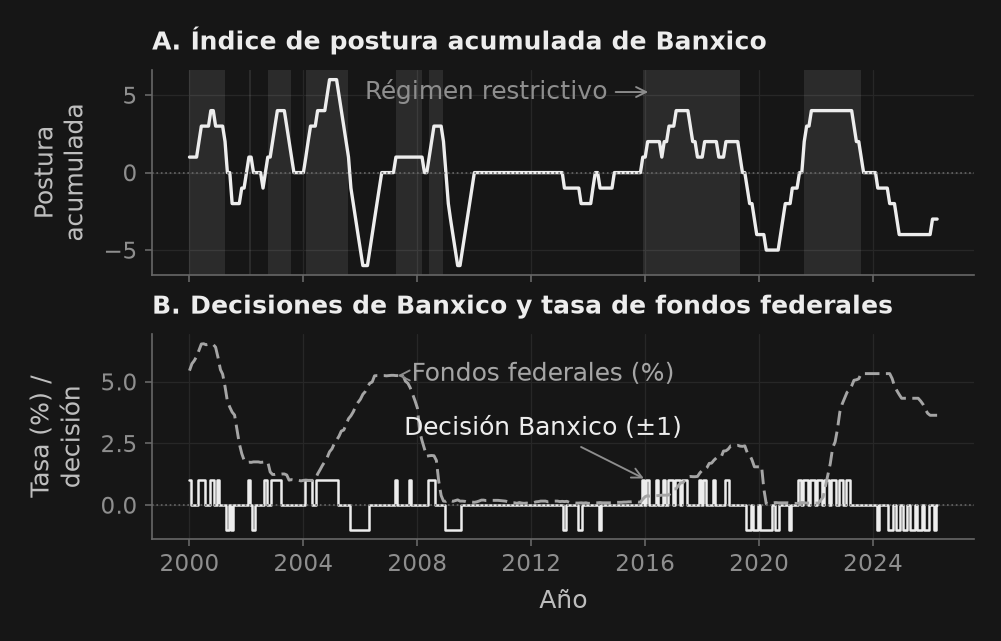

In [7]:
# Visualización macroeconómica en dos paneles
# Dos tiras apiladas con eje x compartido (26 años mensuales); el tamaño lo fija
# el perfil activo (cuaderno o ranura de la lámina), no la celda
fig, (ax1, ax2) = _nbstyle.figura(2, 1, figsize=plt.rcParams["figure.figsize"], sharex=True)

# Panel A: postura acumulada; sombreado a toda altura donde la narrativa comunicó un régimen restrictivo
ax1.plot(df_macro.index, df_macro["banxico_stance_signed"], color=_nbstyle.S1["color"], ls="-", lw=1.6)
ax1.fill_between(
    df_macro.index, 0, 1,
    where=(df_macro["tight_stance_narr"] == 1.0),
    transform=ax1.get_xaxis_transform(), color=_nbstyle.RECESION, lw=0,
)
ax1.axhline(0, color=_nbstyle.SPINE, lw=0.8, ls=":")
# La etiqueta del eje va en dos renglones: en uno solo es más alta que la tira
# (1,14 in contra los 0,98 in de la ranura) y se mete en el título del panel
ax1.set_ylabel("Postura\nacumulada")
ax1.set_title("A. Índice de postura acumulada de Banxico")
ax1.annotate(
    "Régimen restrictivo", xy=(pd.Timestamp("2016-04-01"), 5.2),
    xytext=(pd.Timestamp("2010-06-01"), 5.2), ha="center", va="center",
    color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA,
)

# Panel B: decisiones de Banxico (+1 / 0 / -1) frente a la tasa efectiva de fondos federales
# Los nombres van dentro de los ejes, en el hueco de 2009-2016, con una guía a su serie:
# "auto" los apilaría sobre la onda de decisiones, que ocupa todo el eje entre -1 y +1
ax2.step(df_macro.index, df_macro["banxico_direction"], where="mid", color=_nbstyle.TINTA, ls="-", lw=1.2,
         label="Decisión Banxico (±1)")
ax2.plot(df_macro.index, df_macro["FEDFUNDS"], color=_nbstyle.S2["color"], ls=_nbstyle.S2["linestyle"], lw=1.4,
         label="Fondos federales (%)")
ax2.axhline(0, color=_nbstyle.SPINE, lw=0.8, ls=":")
ax2.set_ylabel("Tasa (%) /\ndecisión")
ax2.set_xlabel("Año")
ax2.set_title("B. Decisiones de Banxico y tasa de fondos federales")
ax2.annotate(
    "Fondos federales (%)", xy=(pd.Timestamp("2007-03-01"), 5.25),
    xytext=(pd.Timestamp("2012-06-01"), 5.3), ha="center", va="center",
    color=_nbstyle.S2["color"], arrowprops=_nbstyle.FLECHA,
)
# El segundo nombre baja a 2,6: a la altura de la ranura, en 3,0 quedaba a 0,09 in
# del primero (menos de un renglón) y los dos se leían como uno solo
ax2.annotate(
    "Decisión Banxico (±1)", xy=(pd.Timestamp("2016-02-01"), 1.0),
    xytext=(pd.Timestamp("2012-06-01"), 2.6), ha="center", va="bottom",
    color=_nbstyle.TINTA, arrowprops=_nbstyle.FLECHA,
)

plt.show()


## 6. Ejercicio Práctico: Evaluación Textual ante Choques de Oferta y Pronóstico

### Motivación Económica
En episodios de estanflación o choques adversos de oferta (como el choque energético de 2022 o disrupciones en cadenas de suministro), la banca central enfrenta un dilema estructural: el shock eleva la inflación pero deprime la actividad económica real. En estos contextos, la orientación futura (*forward guidance*) se vuelve altamente contingente y el tono de los comunicados se matiza con expresiones condicionales de cautela.

### Tarea del Estudiante
1. Clasifique un comunicado representativo de choque de oferta utilizando tanto el diccionario de `puremacro.narrative` como la proyección de similitud coseno frente a los prototipos de política monetaria.
2. Compruebe la coherencia de la postura semántica obtenida.
3. Evalúe el impacto marginal del cambio de régimen narrativo en la tasa esperada según el modelo econométrico estimado.
4. Ejecute el bloque de verificación automática con aserciones para validar sus resultados computacionales y teóricos.

In [8]:
# Tarea del Estudiante: Análisis de comunicado ante choque de oferta
student_statement = (
    "La Junta de Gobierno evaluó el balance de riesgos ante el severo choque de oferta en energéticos y alimentos. "
    "Aunque se reconoce la desaceleración económica y la holgura en el mercado, la persistencia inflacionaria "
    "y el riesgo de desanclaje de expectativas obligan a preservar una postura restrictiva y continuar el ciclo de alzas."
)

# 1. Puntuación con diccionario especializado
student_lex_res = score_spanish_macro_sentiment(student_statement, lexicon=MACRO_LEXICON)
print(f"Puntuación Léxica del Estudiante:")
print(f"  Postura Neta: {student_lex_res.net_stance:+.2f}")
print(f"  Términos Hawkish detectados: {student_lex_res.matched_hawkish}")
print(f"  Términos Dovish detectados: {student_lex_res.matched_dovish}")

# 2. Proyección vectorial en prototipos normativos
X_student = vec.transform([student_statement])
sim_prototypes = X_student @ X_tfidf[2:].T

sim_hawk = float(sim_prototypes[0, 0])
sim_dove = float(sim_prototypes[0, 1])
semantic_stance = (sim_hawk - sim_dove) / (sim_hawk + sim_dove + 1e-9)

print(f"\nProyección Vectorial Semántica:")
print(f"  Similitud con Prototipo Hawkish: {sim_hawk:.3f}")
print(f"  Similitud con Prototipo Dovish:  {sim_dove:.3f}")
print(f"  Postura Semántica Continua:     {semantic_stance:+.3f}")

# 3. Verificaciones de integridad económica y econométrica
assert len(df_macro) > 300, "El panel de Banxico debe contener más de 300 observaciones mensuales"
assert ols_model.params["tight_stance_narr"] > 0.20, "El coeficiente de postura narrativa debe ser positivo y superior a 0.20"
assert ols_model.pvalues["tight_stance_narr"] < 0.01, "La postura narrativa debe ser estadísticamente significativa al 1%"
assert ols_model.rsquared > 0.30, "El R^2 de la regresión predictiva debe superar el 30%"
assert sim_hawk > sim_dove, "El comunicado debe mostrar mayor afinidad con el prototipo restrictivo que con el acomodaticio"
assert student_lex_res.hawkish_count >= 1, "El diccionario debe capturar al menos un término restrictivo clave"

print("\n✓ ¡Todas las verificaciones empíricas y teóricas superadas con éxito!")

Puntuación Léxica del Estudiante:
  Postura Neta: +0.33
  Términos Hawkish detectados: ['postura restrictiva', 'desanclaje de expectativas']
  Términos Dovish detectados: ['desaceleración económica']

Proyección Vectorial Semántica:
  Similitud con Prototipo Hawkish: 0.194
  Similitud con Prototipo Dovish:  0.112
  Postura Semántica Continua:     +0.268

✓ ¡Todas las verificaciones empíricas y teóricas superadas con éxito!


## 7. Síntesis Metodológica y Preguntas de Reflexión

### Orientación Futura Délfica vs. Odiseica
En la literatura monetaria (Campbell, Evans, Fisher y Justiniano, 2012), la orientación futura se divide en dos categorías esenciales:
1. **Forward Guidance Délfico**: El banco central actúa como el oráculo de Delfos, ofreciendo un pronóstico puro sobre las condiciones macroeconómicas y la trayectoria que consideraría adecuada si sus modelos resultan acertados, sin comprometer su acción futura.
2. **Forward Guidance Odiseico**: El banco central emula a Odiseo atándose al mástil para resistir las sirenas, comprometiéndose explícitamente a mantener una trayectoria de tasas (por ejemplo, tasas en cero hasta alcanzar cierto umbral de desempleo), modificando las primas por plazo y resolviendo el problema de inconsistencia temporal de Kydland y Prescott (1977).

### La Crítica de Lucas en el Procesamiento de Lenguaje Natural
Cuando los bancos centrales son conscientes de que los algoritmos de fondos cuantitativos e investigadores leen automáticamente cada adjetivo de sus comunicados, modifican estratégicamente su redacción para evitar reacciones de mercado no deseadas. Este fenómeno constituye una manifestación directa de la **Crítica de Lucas (1976)** aplicada a la lingüística económica: las reglas estadísticas de extracción textual dejan de ser invariantes a los cambios en la política de comunicación.

### Preguntas para el Seminario
1. ¿Cómo distinguir econométricamente si una sorpresa de comunicación refleja información privada del banco central sobre la economía (efecto información) o una alteración no anticipada de su función de reacción monetaria?
2. Si un modelo de lenguaje grande (LLM) procesa oraciones complejas con doble negación (*"no se descarta la no prolongación de la pausa"*), ¿qué ventajas presenta frente a un diccionario léxico tradicional y qué riesgos de sesgo o alucinación introduce?